# Desafio Extra — Enriquecendo os Dados de Produção da Alpha-SP Indústria

Combinando o CSV de produção diária (`alpha_sp_producao_diaria.csv`) com os dados complementares vindos do Excel (`dados_complementares_alpha_sp.xlsx`), para responder a 5 perguntas de análise que dependem do cruzamento das três fontes.

## 1. Carregando as fontes de dados

In [1]:
import pandas as pd

# Producao diaria (arquivo ja trabalhado nas missoes anteriores)
df = pd.read_csv("alpha_sp_producao_diaria.csv", sep=";", decimal=",")
df["data"] = pd.to_datetime(df["data"])

df.head()

,data,maquina,setor,turno,horas_uso,temperatura_media,vibracao_media,producao,pecas_defeituosas,taxa_defeito,eficiencia,col_mes
0,2025-01-01,Torno CNC 03,Usinagem,Manhã,11,76.3,2.45,492,11,2.235772,97.764228,1
1,2025-01-02,Torno CNC 03,Usinagem,Tarde,7,82.1,2.27,457,6,1.312910,98.687090,1
2,2025-01-03,Torno CNC 03,Usinagem,Manhã,8,79.2,2.02,482,7,1.452282,98.547718,1
3,2025-01-04,Torno CNC 03,Usinagem,Tarde,3,77.5,2.16,157,11,7.006369,92.993631,1
4,2025-01-05,Torno CNC 03,Usinagem,Manhã,3,70.7,2.48,162,4,2.469136,97.530864,1


In [2]:
# Dados complementares: duas abas do Excel
cadastro = pd.read_excel("dados_complementares_alpha_sp.xlsx", sheet_name="Cadastro_Maquinas")
metas = pd.read_excel("dados_complementares_alpha_sp.xlsx", sheet_name="Metas_Mensais")

cadastro

,maquina,setor,fabricante,modelo,ano_aquisicao,capacidade_maxima_diaria,custo_hora_operacao_reais,tecnico_responsavel,ultima_manutencao_preventiva
0,Torno CNC 03,Usinagem,Romi,GL 240,2019.0,550.0,42.5,Carlos Mendes,2025-01-15
1,Prensa 12,Estamparia,Schuler,PDS 400,2015.0,400.0,35.8,Fernanda Silva,2025-02-10
2,Solda Robô 01,Soldagem,KUKA,KR 16,2021.0,700.0,58.2,Roberto Alves,2025-03-05
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Observação: dados fictícios criados para fins ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
metas.head(10)

,mes,setor,meta_producao_diaria,meta_taxa_defeito_max_pct
0,Janeiro/2025,Usinagem,500.0,2.50
1,Janeiro/2025,Estamparia,350.0,3.00
2,Janeiro/2025,Soldagem,600.0,2.00
3,Fevereiro/2025,Usinagem,504.0,2.40
4,Fevereiro/2025,Estamparia,354.0,2.90
5,Fevereiro/2025,Soldagem,606.0,1.92
6,Março/2025,Usinagem,508.0,2.30
7,Março/2025,Estamparia,358.0,2.80
8,Março/2025,Soldagem,612.0,1.84
9,Abril/2025,Usinagem,512.0,2.20


## 2. Limpeza dos dados complementares

As duas abas trazem, ao final, uma linha de observação/nota que não é um registro de dado real (ex.: "Observação: dados fictícios..."). Removemos essas linhas usando colunas numéricas obrigatórias como referência, e ajustamos os tipos de dado.

In [4]:
# Remove linhas de observacao/nota (identificadas pela ausencia de valor numerico obrigatorio)
cadastro = cadastro.dropna(subset=["ano_aquisicao"]).copy()
metas = metas.dropna(subset=["meta_producao_diaria"]).copy()

cadastro["ano_aquisicao"] = cadastro["ano_aquisicao"].astype(int)
cadastro["ultima_manutencao_preventiva"] = pd.to_datetime(cadastro["ultima_manutencao_preventiva"])

cadastro

,maquina,setor,fabricante,modelo,ano_aquisicao,capacidade_maxima_diaria,custo_hora_operacao_reais,tecnico_responsavel,ultima_manutencao_preventiva
0,Torno CNC 03,Usinagem,Romi,GL 240,2019,550.0,42.5,Carlos Mendes,2025-01-15
1,Prensa 12,Estamparia,Schuler,PDS 400,2015,400.0,35.8,Fernanda Silva,2025-02-10
2,Solda Robô 01,Soldagem,KUKA,KR 16,2021,700.0,58.2,Roberto Alves,2025-03-05


## 3. Criando a coluna de mês no `df` de produção

Precisamos de uma coluna de mês no mesmo formato usado na aba `Metas_Mensais` (ex.: `"Março/2025"`) para poder cruzar as duas fontes por `mes` + `setor`.

In [5]:
meses_pt = {
    1: "Janeiro", 2: "Fevereiro", 3: "Março", 4: "Abril",
    5: "Maio", 6: "Junho", 7: "Julho", 8: "Agosto",
    9: "Setembro", 10: "Outubro", 11: "Novembro", 12: "Dezembro",
}

df["mes"] = df["data"].dt.month.map(meses_pt) + "/" + df["data"].dt.year.astype(str)
df[["data", "mes"]].head()

,data,mes
0,2025-01-01,Janeiro/2025
1,2025-01-02,Janeiro/2025
2,2025-01-03,Janeiro/2025
3,2025-01-04,Janeiro/2025
4,2025-01-05,Janeiro/2025


## 4. Combinando (merge) as três fontes

1. `df` (produção) + `cadastro` (Cadastro_Maquinas), pela coluna `maquina`.
2. Resultado + `metas` (Metas_Mensais), pelas colunas `mes` e `setor` (chave composta).

In [6]:
# Merge 1: producao + cadastro das maquinas (chave: maquina)
df_completo = df.merge(cadastro, on="maquina", how="left", suffixes=("", "_cadastro"))

# Merge 2: resultado + metas mensais (chave composta: mes e setor)
df_unificado = df_completo.merge(metas, on=["mes", "setor"], how="left")

print(f"Linhas em df (producao): {len(df)}")
print(f"Linhas em df_unificado (apos os merges): {len(df_unificado)}")
print(f"Valores ausentes apos o merge:\n{df_unificado.isna().sum().sum()} valores nulos no total")

df_unificado.to_csv("df_unificado.csv", index=False)
df_unificado.head()

Linhas em df (producao): 543
Linhas em df_unificado (apos os merges): 543
Valores ausentes apos o merge:
0 valores nulos no total


,data,maquina,setor,turno,horas_uso,temperatura_media,vibracao_media,producao,pecas_defeituosas,taxa_defeito,...,setor_cadastro,fabricante,modelo,ano_aquisicao,capacidade_maxima_diaria,custo_hora_operacao_reais,tecnico_responsavel,ultima_manutencao_preventiva,meta_producao_diaria,meta_taxa_defeito_max_pct
0,2025-01-01,Torno CNC 03,Usinagem,Manhã,11,76.3,2.45,492,11,2.235772,...,Usinagem,Romi,GL 240,2019,550.0,42.5,Carlos Mendes,2025-01-15,500.0,2.5
1,2025-01-02,Torno CNC 03,Usinagem,Tarde,7,82.1,2.27,457,6,1.312910,...,Usinagem,Romi,GL 240,2019,550.0,42.5,Carlos Mendes,2025-01-15,500.0,2.5
2,2025-01-03,Torno CNC 03,Usinagem,Manhã,8,79.2,2.02,482,7,1.452282,...,Usinagem,Romi,GL 240,2019,550.0,42.5,Carlos Mendes,2025-01-15,500.0,2.5
3,2025-01-04,Torno CNC 03,Usinagem,Tarde,3,77.5,2.16,157,11,7.006369,...,Usinagem,Romi,GL 240,2019,550.0,42.5,Carlos Mendes,2025-01-15,500.0,2.5
4,2025-01-05,Torno CNC 03,Usinagem,Manhã,3,70.7,2.48,162,4,2.469136,...,Usinagem,Romi,GL 240,2019,550.0,42.5,Carlos Mendes,2025-01-15,500.0,2.5


## 5. Perguntas de análise

Com as três fontes já combinadas em `df_unificado`, respondemos às 5 perguntas propostas.

### Pergunta 1 — Custo total de operação

Considerando `horas_uso × custo_hora_operacao_reais`, qual foi o custo total de operação de cada máquina ao longo dos 6 meses? Qual delas foi a mais cara para operar?

In [7]:
df_unificado["custo_operacao_dia"] = df_unificado["horas_uso"] * df_unificado["custo_hora_operacao_reais"]

custo_total_por_maquina = (
    df_unificado.groupby("maquina")["custo_operacao_dia"]
    .sum()
    .sort_values(ascending=False)
)

print(custo_total_por_maquina)

# Conclusao: a Solda Robo 01 foi a maquina mais cara para operar ao longo dos 6 meses
# (aprox. R$ 69.665,40), seguida pela Torno CNC 03 e, por ultimo, a Prensa 12
# (mais barata de operar no periodo).

maquina
Solda Robô 01    69665.4
Torno CNC 03     51297.5
Prensa 12        42387.2
Name: custo_operacao_dia, dtype: float64


### Pergunta 2 — Máquinas x idade x qualidade

Existe alguma relação entre o `ano_aquisicao` da máquina e sua taxa média de defeito (`pecas_defeituosas / producao`)? As máquinas mais antigas realmente apresentam mais defeitos?

In [8]:
df_unificado["taxa_defeito_pct"] = (df_unificado["pecas_defeituosas"] / df_unificado["producao"]) * 100

relacao_idade_defeito = (
    df_unificado.groupby(["maquina", "ano_aquisicao"])["taxa_defeito_pct"]
    .mean()
    .reset_index()
    .sort_values("ano_aquisicao")
)

print(relacao_idade_defeito)

# Conclusao: sim, existe uma relacao clara entre idade e taxa de defeito: a Prensa 12,
# a mais antiga (2015), tem a maior taxa media de defeito (~3,94%); a Torno CNC 03 (2019)
# fica no meio (~2,01%); e a Solda Robo 01, a mais nova (2021), tem a menor taxa (~1,68%).
# Quanto mais antiga a maquina, maior a taxa media de defeito observada.

         maquina  ano_aquisicao  taxa_defeito_pct
0      Prensa 12           2015          3.939795
2   Torno CNC 03           2019          2.009038
1  Solda Robô 01           2021          1.678408


### Pergunta 3 — Metas de produção

Em quantos dias, e em quais meses/setores, a produção diária ficou abaixo da `meta_producao_diaria` definida para aquele mês e setor?

In [9]:
df_unificado["abaixo_da_meta_producao"] = df_unificado["producao"] < df_unificado["meta_producao_diaria"]

total_dias_abaixo_meta = df_unificado["abaixo_da_meta_producao"].sum()

# Ordena os meses cronologicamente (jan a jun), nao em ordem alfabetica
ordem_meses = ["Janeiro/2025", "Fevereiro/2025", "Março/2025", "Abril/2025", "Maio/2025", "Junho/2025"]
df_unificado["mes"] = pd.Categorical(df_unificado["mes"], categories=ordem_meses, ordered=True)

dias_abaixo_por_mes_setor = (
    df_unificado[df_unificado["abaixo_da_meta_producao"]]
    .groupby(["mes", "setor"], observed=True)
    .size()
    .reset_index(name="dias_abaixo_da_meta")
    .sort_values("mes")
)

print(f"Total de dias abaixo da meta de producao: {total_dias_abaixo_meta}\n")
print(dias_abaixo_por_mes_setor.to_string(index=False))

# Conclusao: dos 543 dias-maquina registrados, 388 ficaram abaixo da meta de producao.
# O setor de Estamparia e o que mais frequentemente fica abaixo da meta em todos os meses,
# enquanto Soldagem e o setor que mais consistentemente bate a meta de producao.

Total de dias abaixo da meta de producao: 388

           mes      setor  dias_abaixo_da_meta
  Janeiro/2025 Estamparia                   28
  Janeiro/2025   Soldagem                   15
  Janeiro/2025   Usinagem                   28
Fevereiro/2025 Estamparia                   24
Fevereiro/2025   Soldagem                   10
Fevereiro/2025   Usinagem                   22
    Março/2025   Soldagem                   16
    Março/2025   Usinagem                   26
    Março/2025 Estamparia                   26
    Abril/2025 Estamparia                   29
    Abril/2025   Soldagem                   14
    Abril/2025   Usinagem                   22
     Maio/2025 Estamparia                   30
     Maio/2025   Soldagem                   11
     Maio/2025   Usinagem                   24
    Junho/2025   Soldagem                   17
    Junho/2025 Estamparia                   27
    Junho/2025   Usinagem                   19


### Pergunta 4 — Metas de qualidade

Em quantos dias a taxa de defeito do dia (`pecas_defeituosas / producao × 100`) ultrapassou a `meta_taxa_defeito_max_pct` daquele mês/setor? Qual setor descumpriu a meta com mais frequência?

In [10]:
df_unificado["acima_meta_defeito"] = df_unificado["taxa_defeito_pct"] > df_unificado["meta_taxa_defeito_max_pct"]

total_dias_acima_defeito = df_unificado["acima_meta_defeito"].sum()

freq_descumprimento_por_setor = (
    df_unificado[df_unificado["acima_meta_defeito"]]["setor"]
    .value_counts()
)

print(f"Total de dias com taxa de defeito acima da meta: {total_dias_acima_defeito}\n")
print(freq_descumprimento_por_setor)

setor_mais_descumpriu = freq_descumprimento_por_setor.idxmax()
print(f"\nSetor que mais descumpriu a meta de qualidade: {setor_mais_descumpriu}")

# Conclusao: em 169 dos 543 dias registrados a taxa de defeito ultrapassou a meta definida
# para o mes/setor. A Estamparia e o setor que mais descumpre a meta de qualidade
# (79 dias), quase o dobro do segundo colocado (Soldagem, 46 dias).

Total de dias com taxa de defeito acima da meta: 169

setor
Estamparia    79
Soldagem      46
Usinagem      44
Name: count, dtype: int64

Setor que mais descumpriu a meta de qualidade: Estamparia


Como pede o desafio, respondemos também com um gráfico — aqui, a frequência de dias com taxa de defeito acima da meta, por setor:

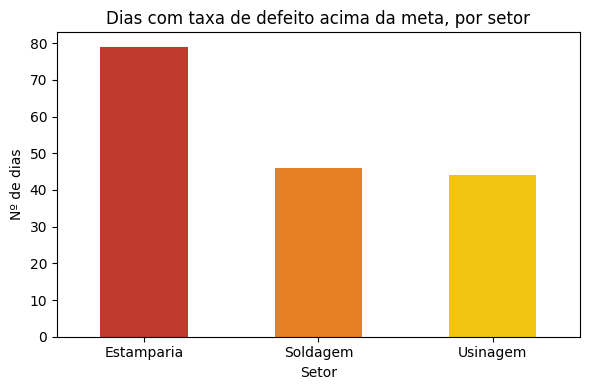

In [11]:
import matplotlib.pyplot as plt

ax = freq_descumprimento_por_setor.sort_values(ascending=False).plot(
    kind="bar",
    color=["#c0392b", "#e67e22", "#f1c40f"],
    figsize=(6, 4),
)
ax.set_title("Dias com taxa de defeito acima da meta, por setor")
ax.set_xlabel("Setor")
ax.set_ylabel("Nº de dias")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Pergunta 5 — Capacidade x realidade

Comparando a produção média diária de cada máquina com sua `capacidade_maxima_diaria` cadastrada, qual máquina opera mais próxima do limite de capacidade e qual tem mais folga?

In [12]:
capacidade_realidade = (
    df_unificado.groupby("maquina")
    .agg(
        producao_media_diaria=("producao", "mean"),
        capacidade_maxima_diaria=("capacidade_maxima_diaria", "first"),
    )
    .reset_index()
)

capacidade_realidade["percentual_capacidade"] = (
    capacidade_realidade["producao_media_diaria"] / capacidade_realidade["capacidade_maxima_diaria"] * 100
)

capacidade_realidade = capacidade_realidade.sort_values("percentual_capacidade", ascending=False)

print(capacidade_realidade.to_string(index=False))

# Conclusao: a Solda Robo 01 opera mais proxima do seu limite de capacidade (~73,6%),
# seguida bem de perto pela Torno CNC 03 (~73,6%). A Prensa 12 e a que tem mais folga,
# operando em media a apenas ~66,3% da sua capacidade maxima diaria.

      maquina  producao_media_diaria  capacidade_maxima_diaria  percentual_capacidade
Solda Robô 01             515.425414                     700.0              73.632202
 Torno CNC 03             404.679558                     550.0              73.578101
    Prensa 12             265.237569                     400.0              66.309392


## 6. Conclusão geral

O cruzamento das três fontes (produção diária, cadastro das máquinas e metas mensais) mostrou que:

- A **Solda Robô 01** é a máquina mais cara de operar, mas também a que trabalha mais próxima da sua capacidade máxima.
- A **Prensa 12**, mais antiga da fábrica, apresenta a maior taxa de defeito e opera com mais folga de capacidade.
- O setor de **Estamparia** é o que mais frequentemente fica abaixo das metas de produção e de qualidade, sendo o principal ponto de atenção para a gestão.